<a href="https://colab.research.google.com/github/kalpatapusridatta-27/Vehicle-Resale-Prediction/blob/main/vehice_resale_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Vehicle_dataset.csv to Vehicle_dataset.csv


In [ ]:
import os
os.listdir()


['.config', 'Vehicle_dataset.csv', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv("Vehicle_dataset.csv")
df.head()


,vehicle_type,engine_cc,fuel_type,vehicle_age_years,mileage_kmpl,service_count,avg_speed_kmph,distance_travelled_km,maintenance_cost,accident_history,resale_value
0,Truck,1047,Electric,0,27.54,15,36.19,246273,139844.56,0,39659.16
1,Bus,670,Petrol,17,39.73,0,34.16,148518,105719.90,1,699799.47
2,Car,864,Hybrid,2,29.34,4,83.84,145002,106531.25,1,1321656.01
3,Truck,869,Electric,12,21.75,17,34.92,127930,19694.62,1,1430393.92
4,Truck,2406,Petrol,1,19.12,22,40.35,204751,38355.38,1,357892.77


In [ ]:
df.shape


(200000, 11)

In [ ]:
df.columns


Index(['vehicle_type', 'engine_cc', 'fuel_type', 'vehicle_age_years',
       'mileage_kmpl', 'service_count', 'avg_speed_kmph',
       'distance_travelled_km', 'maintenance_cost', 'accident_history',
       'resale_value'],
      dtype='object')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   vehicle_type           200000 non-null  object 
 1   engine_cc              200000 non-null  int64  
 2   fuel_type              200000 non-null  object 
 3   vehicle_age_years      200000 non-null  int64  
 4   mileage_kmpl           200000 non-null  float64
 5   service_count          200000 non-null  int64  
 6   avg_speed_kmph         200000 non-null  float64
 7   distance_travelled_km  200000 non-null  int64  
 8   maintenance_cost       200000 non-null  float64
 9   accident_history       200000 non-null  int64  
 10  resale_value           200000 non-null  float64
dtypes: float64(4), int64(5), object(2)
memory usage: 16.8+ MB


In [ ]:
df.head()


,vehicle_type,engine_cc,fuel_type,vehicle_age_years,mileage_kmpl,service_count,avg_speed_kmph,distance_travelled_km,maintenance_cost,accident_history,resale_value
0,Truck,1047,Electric,0,27.54,15,36.19,246273,139844.56,0,39659.16
1,Bus,670,Petrol,17,39.73,0,34.16,148518,105719.90,1,699799.47
2,Car,864,Hybrid,2,29.34,4,83.84,145002,106531.25,1,1321656.01
3,Truck,869,Electric,12,21.75,17,34.92,127930,19694.62,1,1430393.92
4,Truck,2406,Petrol,1,19.12,22,40.35,204751,38355.38,1,357892.77


In [ ]:
df.isnull().sum()


,0
vehicle_type,0
engine_cc,0
fuel_type,0
vehicle_age_years,0
mileage_kmpl,0
service_count,0
avg_speed_kmph,0
distance_travelled_km,0
maintenance_cost,0
accident_history,0


In [ ]:
# Fill numerical columns
df.fillna(df.median(numeric_only=True), inplace=True)

# Fill categorical columns
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipython-input-1224565786.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
X = df.drop("resale_value", axis=1)
y = df["resale_value"]


In [ ]:
X = pd.get_dummies(X, drop_first=True)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1   # Uses all CPU cores
)

model.fit(X_train, y_train)


RandomForestRegressor(n_jobs=-1, random_state=42)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 371338.44898814755
RMSE: 430546.4924309841


In [ ]:
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))


Train Score: 0.857321445093154
Test Score: -0.022691256656853787


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.head(10)


,Feature,Importance
6,maintenance_cost,0.151367
5,distance_travelled_km,0.151079
4,avg_speed_kmph,0.149863
0,engine_cc,0.147717
2,mileage_kmpl,0.147479
3,service_count,0.089205
1,vehicle_age_years,0.077963
7,accident_history,0.015209
10,vehicle_type_Truck,0.012969
9,vehicle_type_Car,0.012641


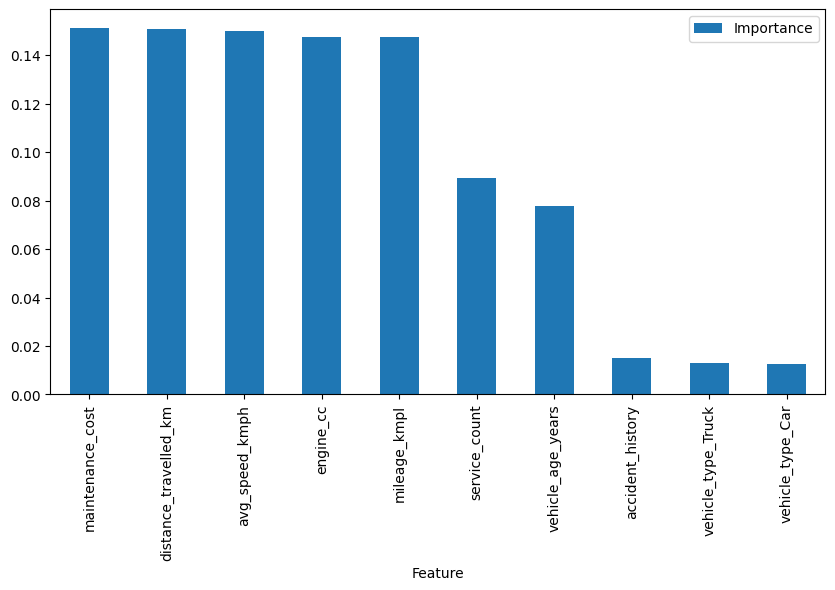

In [ ]:
import matplotlib.pyplot as plt

importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)
plt.show()


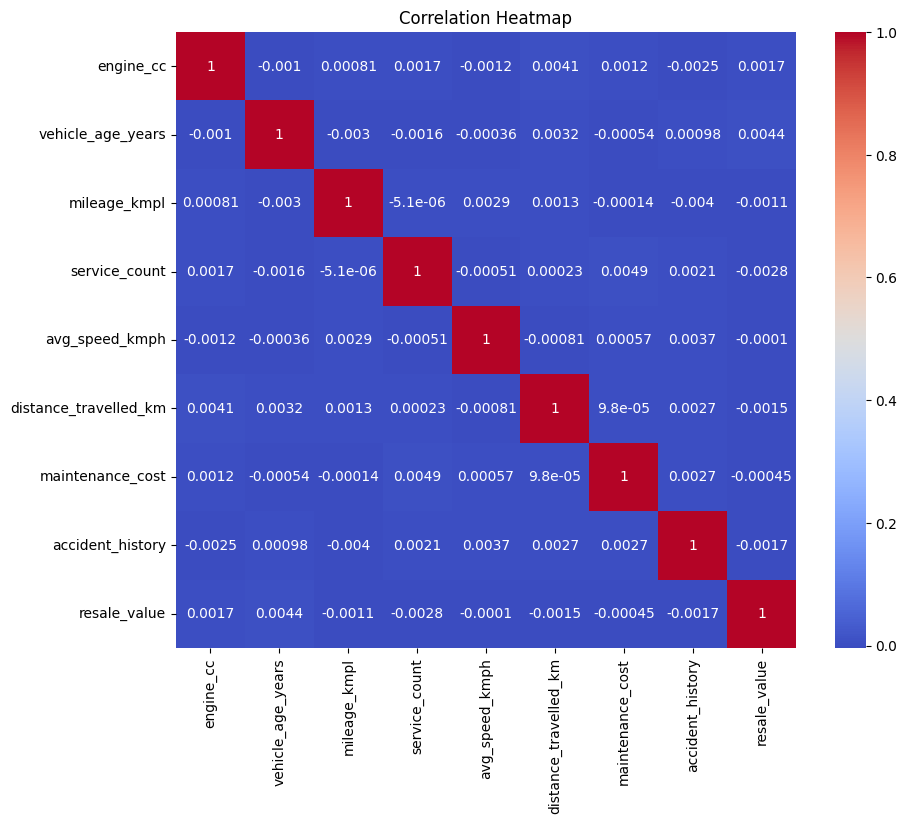

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


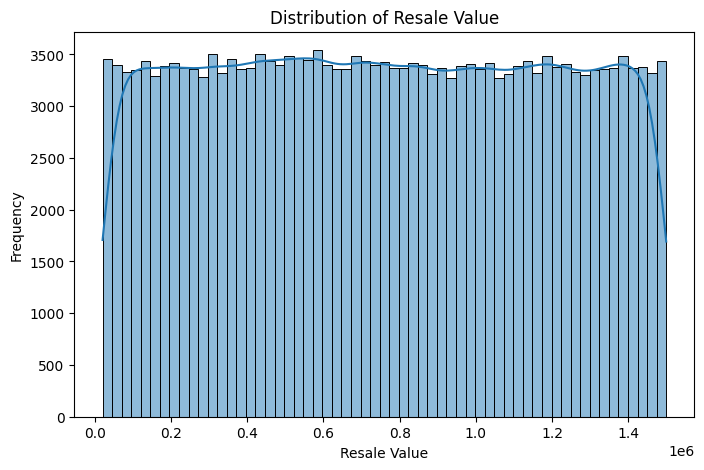

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["resale_value"], kde=True)
plt.title("Distribution of Resale Value")
plt.xlabel("Resale Value")
plt.ylabel("Frequency")
plt.show()


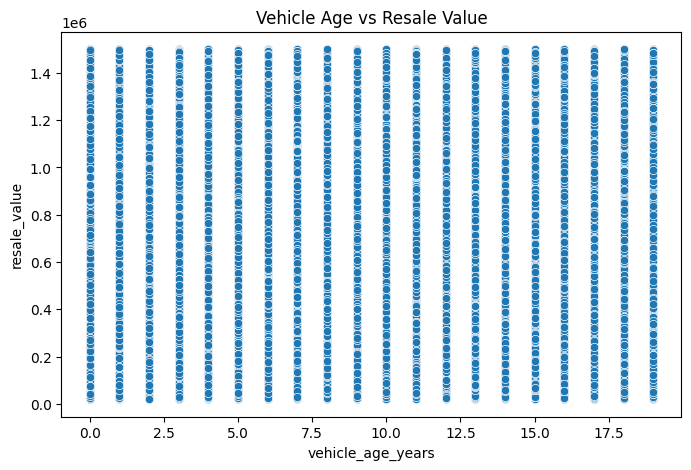

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="vehicle_age_years", y="resale_value", data=df)
plt.title("Vehicle Age vs Resale Value")
plt.show()


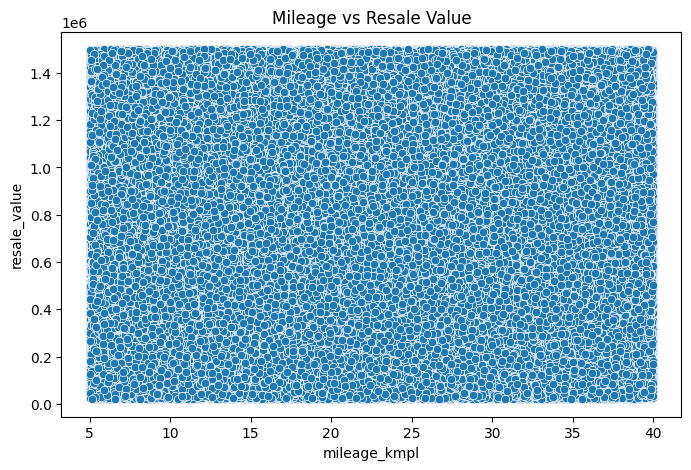

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="mileage_kmpl", y="resale_value", data=df)
plt.title("Mileage vs Resale Value")
plt.show()


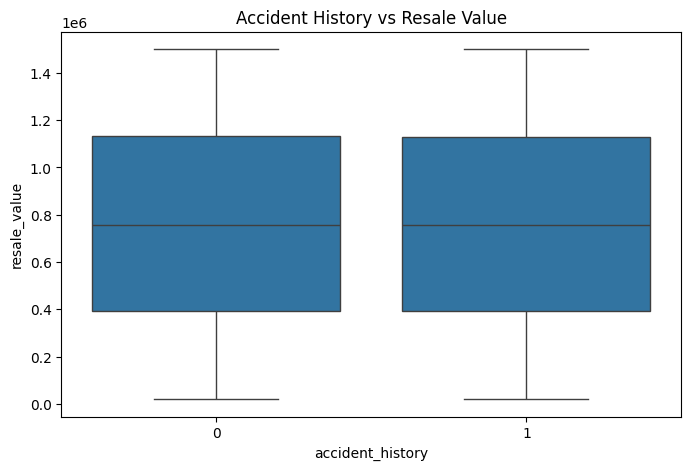

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="accident_history", y="resale_value", data=df)
plt.title("Accident History vs Resale Value")
plt.show()


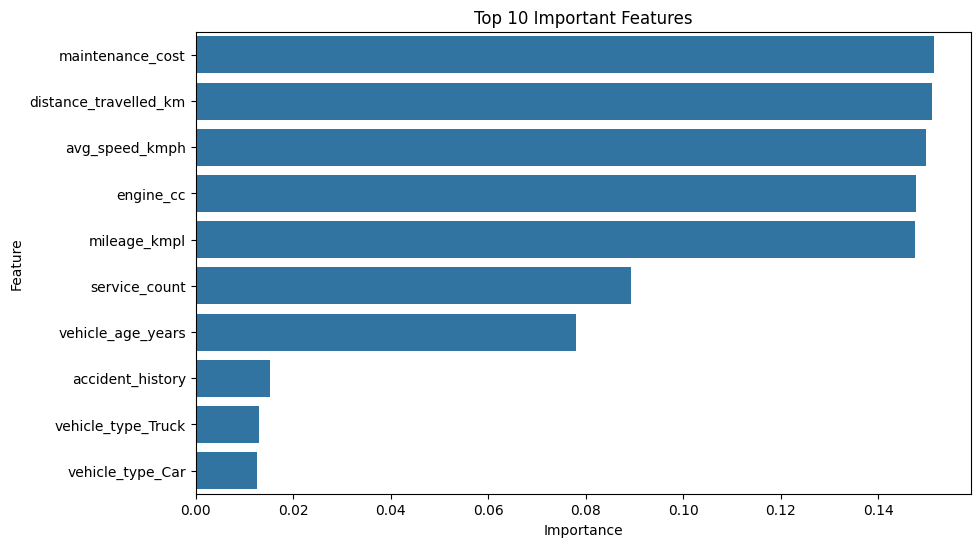

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance.head(10))
plt.title("Top 10 Important Features")
plt.show()


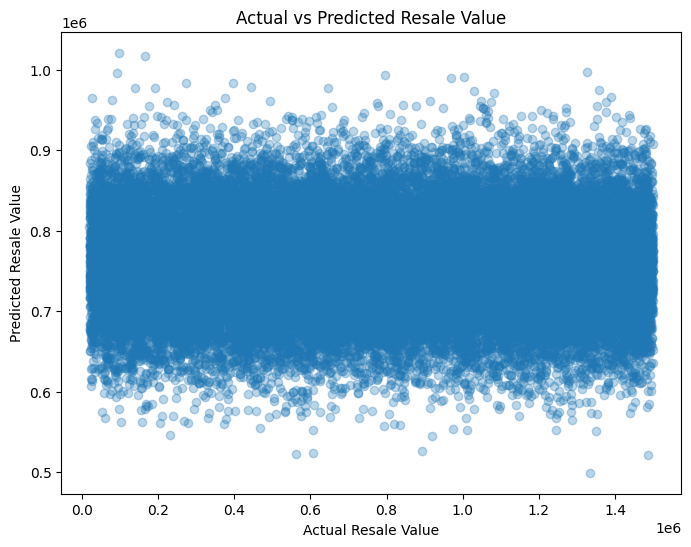

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Resale Value")
plt.ylabel("Predicted Resale Value")
plt.title("Actual vs Predicted Resale Value")
plt.show()


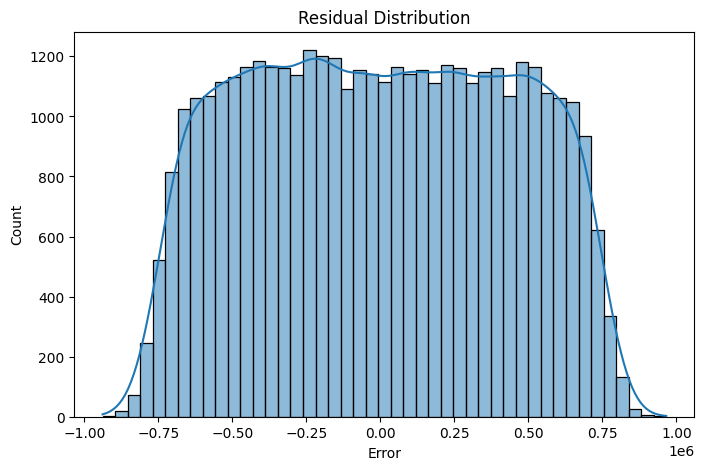

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.show()
